=== Модуль 1: Загрузка и подготовка данных SkyMarket (Фитнес-Кафе) ===
Успешно импортировано транзакций: 721

=== Модуль 2: Сборный анализ и проверка гипотез ===

1. Анализ выручки по типам клиентов:


,Customer type,mean,median,count
0,Member,287.176627,254.480,415
1,VIP,251.730915,193.735,306



2. Анализ выручки по линейкам продуктов:


,Product line,mean,median,count
0,Абонементы,261.532273,204.570,110
1,ЗОЖ-Кафе,269.126885,228.120,122
2,Персональные тренировки,262.057299,217.800,137
3,СПА-услуги,286.253909,255.315,110
4,Спортивное питание,285.674308,244.935,130
5,Фитнес-гаджеты,268.557946,222.705,112



=== РАСЧЕТ ДЛЯ ВСЕГО ДАТАФРЕЙМА (Unit price и Rating) ===


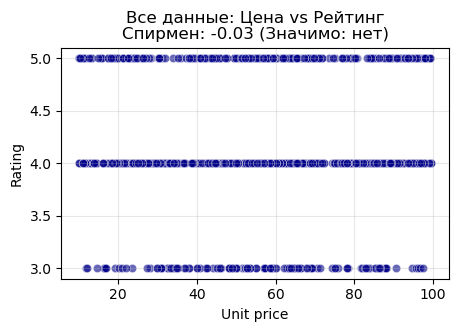


=== РАСЧЕТ ПО СЕГМЕНТАМ (В ЦИКЛЕ FOR) ===


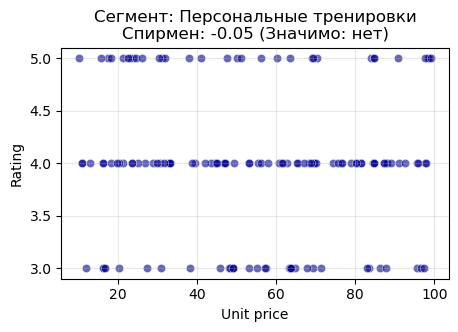

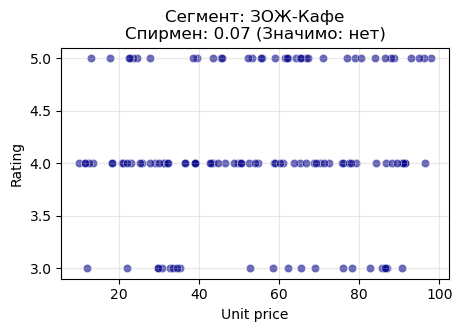

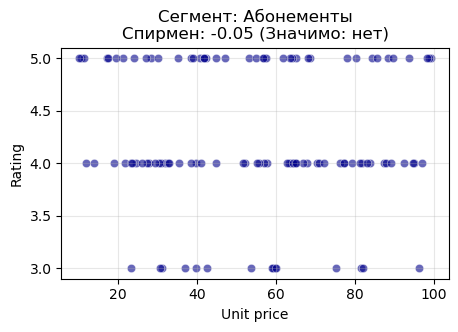

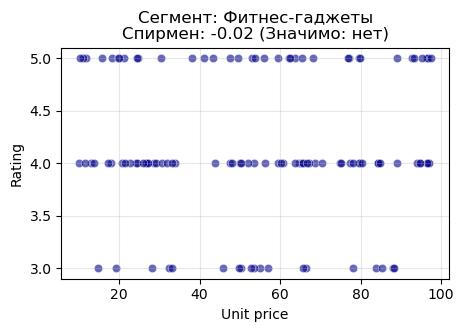

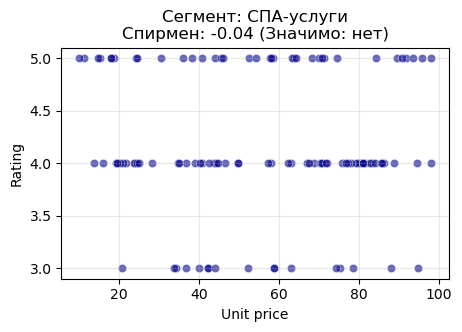

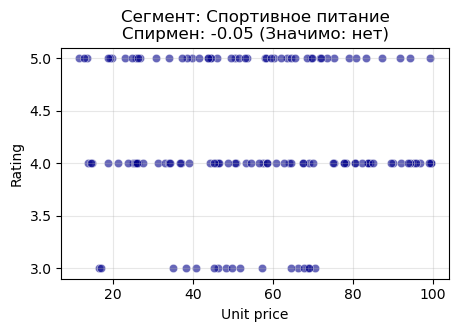


=== Модуль 3: Экспорт финансовой календарной сетки в Excel ===

[УСПЕХ] Настроенный Excel-календарь с формулами и подсветкой сохранен в папку проекта: generated/fitness_club_financial_calendar.xlsx


In [7]:
# Автоматически создаем папку для сохранения файлов, чтобы код не падал
os.makedirs('generated', exist_ok=True)

# ==========================================
# МОДУЛЬ 1: ЭМУЛЯЦИЯ БАЗЫ ДАННЫХ & РИТЕЙЛА
# ==========================================
print("=== Модуль 1: Загрузка и подготовка данных SkyMarket (Фитнес-Кафе) ===")
np.random.seed(42)
n_rows = 721
dates = pd.date_range(start="2026-09-19", end="2026-10-31", periods=n_rows)

product_lines = ['Спортивное питание', 'Фитнес-гаджеты', 'Абонементы', 'Персональные тренировки', 'ЗОЖ-Кафе', 'СПА-услуги']
customer_types = ['Member', 'VIP']

df = pd.DataFrame({
    'Invoice ID': [f"INV-{i}" for i in range(1000, 1000 + n_rows)],
    'Date': dates,
    'Product line': np.random.choice(product_lines, n_rows),
    'Customer type': np.random.choice(customer_types, n_rows, p=[0.58, 0.42]),
    'Unit price': np.random.uniform(10, 100, n_rows).round(2),
    'Quantity': np.random.randint(1, 10, n_rows),
    'Rating': np.random.choice([3.0, 4.0, 5.0], n_rows, p=[0.2, 0.5, 0.3])
})
df['Total_price'] = (df['Unit price'] * df['Quantity']).round(2)
print(f"Успешно импортировано транзакций: {len(df)}")

# ==========================================
# МОДУЛЬ 2: СТАТИСТИКА И КОРРЕЛЯЦИЯ (С ГРАФИКАМИ)
# ==========================================
print("\n=== Модуль 2: Сборный анализ и проверка гипотез ===")

print("\n1. Анализ выручки по типам клиентов:")
display(df.groupby('Customer type')['Total_price'].agg(['mean', 'median', 'count']).reset_index())

print("\n2. Анализ выручки по линейкам продуктов:")
display(df.groupby('Product line')['Total_price'].agg(['mean', 'median', 'count']).reset_index())

# Функция корреляции со скаттерплотом
def calculate_correlations(x_1, x_2, title_name, alpha=0.05):
    p_coef, _ = pearsonr(x_1, x_2)
    spearman_coef, p_value = spearmanr(x_1, x_2)
    is_significant = "да" if p_value < alpha else "нет"
    
    # Строим диаграмму рассеивания (Scatter plot)
    plt.figure(figsize=(5, 3))
    sns.scatterplot(x=x_1, y=x_2, color='darkblue', alpha=0.6)
    plt.title(f'{title_name}\nСпирмен: {spearman_coef:.2f} (Значимо: {is_significant})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return p_coef, spearman_coef, is_significant

print("\n=== РАСЧЕТ ДЛЯ ВСЕГО ДАТАФРЕЙМА (Unit price и Rating) ===")
p_all, s_all, sig_all = calculate_correlations(df['Unit price'], df['Rating'], "Все данные: Цена vs Рейтинг")

print("\n=== РАСЧЕТ ПО СЕГМЕНТАМ (В ЦИКЛЕ FOR) ===")
for line in df['Product line'].unique():
    segment_data = df[df['Product line'] == line]
    p_seg, s_seg, sig_seg = calculate_correlations(segment_data['Unit price'], segment_data['Rating'], f"Сегмент: {line}")

# ==========================================
# МОДУЛЬ 3: ЭКСПОРТ В EXCEL-КАЛЕНДАРЬ
# ==========================================
print("\n=== Модуль 3: Экспорт финансовой календарной сетки в Excel ===")
daily_summary = df.groupby([df['Date'].dt.date, 'Product line'])['Total_price'].sum().unstack(fill_value=0)
daily_summary.index = pd.to_datetime(daily_summary.index)
all_dates = pd.date_range(start="2026-09-19", end="2026-10-31")

wb = Workbook()
ws = wb.active
ws.title = "Календарная сетка"

# Включаем сетку в Excel
ws.sheet_view.showGridLines = True

font_base = Font(name="Segoe UI", size=10)
font_bold = Font(name="Segoe UI", size=10, bold=True)
font_white = Font(name="Segoe UI", size=10, bold=True, color="FFFFFF")
fill_header = PatternFill(start_color="333333", end_color="333333", fill_type="solid")
fill_weekend = PatternFill(start_color="F9EBEA", end_color="F9EBEA", fill_type="solid")
fill_total = PatternFill(start_color="E8F8F5", end_color="E8F8F5", fill_type="solid")
thin_border = Border(left=Side(style='thin', color='D0D3D4'), right=Side(style='thin', color='D0D3D4'), top=Side(style='thin', color='D0D3D4'), bottom=Side(style='thin', color='D0D3D4'))

ws['A1'] = "Категория / Дата"
ws['A1'].font = font_bold

for idx, cat in enumerate(product_lines, start=2):
    ws.cell(row=idx, column=1, value=cat).font = font_base
ws.cell(row=8, column=1, value="Доход клубов (СБП/АМТ)").font = font_base

for col_idx, d in enumerate(all_dates, start=2):
    cell_date = ws.cell(row=1, column=col_idx, value=d.strftime("%d.%m"))
    cell_date.font = font_white
    cell_date.fill = fill_header
    cell_date.alignment = Alignment(horizontal="center")
    is_weekend = d.weekday() >= 5
    
    for row_idx, cat in enumerate(product_lines, start=2):
        val = daily_summary.loc[d, cat] if (d in daily_summary.index and cat in daily_summary.columns) else 0
        cell = ws.cell(row=row_idx, column=col_idx, value=val)
        cell.font = font_base
        cell.number_format = '#,##0;[Red]-#,##0;"-"'
        cell.border = thin_border
        if is_weekend: cell.fill = fill_weekend
            
    # Задаем фиксированный список случайных пополнений
    inc_val = np.random.choice([0, 15000, 25000, 45000], p=[0.6, 0.2, 0.1, 0.1])
    cell_inc = ws.cell(row=8, column=col_idx, value=inc_val)
    cell_inc.font = Font(name="Segoe UI", size=10, color="27AE60")
    cell_inc.number_format = '#,##0;[Red]-#,##0;"-"'
    cell_inc.border = thin_border
    if is_weekend: cell_inc.fill = fill_weekend

row_total_exp = 9
ws.cell(row=row_total_exp, column=1, value="ИТОГО РАСХОДОВ").font = font_bold
for col_idx in range(2, len(all_dates) + 2):
    col_letter = get_column_letter(col_idx)
    cell_tot = ws.cell(row=row_total_exp, column=col_idx, value=f"=SUM({col_letter}2:{col_letter}7)")
    cell_tot.font = font_bold
    cell_tot.fill = fill_total
    cell_tot.number_format = '#,##0;[Red]-#,##0;"-"'
    cell_tot.border = thin_border

for col in ws.columns:
    max_len = max(len(str(cell.value or '')) for cell in col)
    col_letter = get_column_letter(col[0].column) # Берём номер колонки из первой ячейки кортежа
    ws.column_dimensions[col_letter].width = max(max_len + 2, 8)
ws.column_dimensions['A'].width = 25

output_file = "generated/fitness_club_financial_calendar.xlsx"
wb.save(output_file)
print(f"\n[УСПЕХ] Настроенный Excel-календарь с формулами и подсветкой сохранен в папку проекта: {output_file}")